In [ ]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Libraries loaded ✅")

Libraries loaded ✅


In [ ]:
#Load All 5 CSVs
data_path = '../data/raw/'

accounts      = pd.read_csv(data_path + 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(data_path + 'ravenstack_subscriptions.csv')
usage         = pd.read_csv(data_path + 'ravenstack_feature_usage.csv')
tickets       = pd.read_csv(data_path + 'ravenstack_support_tickets.csv')
churn         = pd.read_csv(data_path + 'ravenstack_churn_events.csv')

# Data inventory
tables = {
    'accounts':      accounts,
    'subscriptions': subscriptions,
    'feature_usage': usage,
    'support_tickets': tickets,
    'churn_events':  churn
}

print("=" * 55)
print(f"{'Table':<22} {'Rows':>8} {'Columns':>8}")
print("=" * 55)
for name, df in tables.items():
    print(f"{name:<22} {df.shape[0]:>8,} {df.shape[1]:>8}")
print("=" * 55)

Table                      Rows  Columns
accounts                    500       10
subscriptions             5,000       14
feature_usage            25,000        8
support_tickets           2,000        9
churn_events                600        9


In [ ]:
# Data Profiling (Nulls & Dtypes)
def profile_table(name, df):
    print(f"\n{'='*55}")
    print(f"TABLE: {name.upper()}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'Column':<35} {'Dtype':<12} {'Nulls':>6} {'Null%':>7}")
    print("-" * 62)
    for col in df.columns:
        nulls = df[col].isnull().sum()
        pct   = nulls / len(df) * 100
        print(f"{col:<35} {str(df[col].dtype):<12} {nulls:>6} {pct:>6.1f}%")

for name, df in tables.items():
    profile_table(name, df)


TABLE: ACCOUNTS
Shape: 500 rows × 10 columns
Column                              Dtype         Nulls   Null%
--------------------------------------------------------------
account_id                          object            0    0.0%
account_name                        object            0    0.0%
industry                            object            0    0.0%
country                             object            0    0.0%
signup_date                         object            0    0.0%
referral_source                     object            0    0.0%
plan_tier                           object            0    0.0%
seats                               int64             0    0.0%
is_trial                            bool              0    0.0%
churn_flag                          bool              0    0.0%

TABLE: SUBSCRIPTIONS
Shape: 5,000 rows × 14 columns
Column                              Dtype         Nulls   Null%
--------------------------------------------------------------
subscri

In [ ]:
#Fix Data Types
# Fix date columns — using actual CSV column names
accounts['signup_date']         = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date']     = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date']       = pd.to_datetime(subscriptions['end_date'])
tickets['submitted_at']         = pd.to_datetime(tickets['submitted_at'])
tickets['closed_at']            = pd.to_datetime(tickets['closed_at'])
churn['churn_date']             = pd.to_datetime(churn['churn_date'])
usage['usage_date']             = pd.to_datetime(usage['usage_date'])

# Standardize boolean columns to 0/1
# Note: the CSVs already loaded booleans as bool dtype,
# but we cast to int for consistent math operations
bool_cols = {
    'accounts':      ['is_trial', 'churn_flag'],
    'subscriptions': ['is_trial', 'upgrade_flag', 'downgrade_flag',
                      'churn_flag', 'auto_renew_flag'],
    'usage':         ['is_beta_feature'],
    'tickets':       ['escalation_flag'],
    'churn':         ['preceding_upgrade_flag', 'preceding_downgrade_flag',
                      'is_reactivation']
}

dfs = {
    'accounts': accounts, 'subscriptions': subscriptions,
    'usage': usage, 'tickets': tickets, 'churn': churn
}

for table_name, cols in bool_cols.items():
    df = dfs[table_name]
    for col in cols:
        df[col] = df[col].astype(str).str.lower().map(
            {'true': 1, 'false': 0}
        )

print("Data types fixed ✅")
print(f"\nAccounts dtypes:\n{accounts.dtypes}")

Data types fixed ✅

Accounts dtypes:
account_id                 object
account_name               object
industry                   object
country                    object
signup_date        datetime64[ns]
referral_source            object
plan_tier                  object
seats                       int64
is_trial                    int64
churn_flag                  int64
dtype: object


In [ ]:
# DUPLICATE CHECKS — using actual snake_case column names
print("DUPLICATE CHECKS")
print("=" * 55)
print(f"accounts       - duplicate account_ids:       {accounts['account_id'].duplicated().sum()}")
print(f"subscriptions  - duplicate subscription_ids:  {subscriptions['subscription_id'].duplicated().sum()}")
print(f"usage          - duplicate usage_ids:         {usage['usage_id'].duplicated().sum()}")
print(f"tickets        - duplicate ticket_ids:        {tickets['ticket_id'].duplicated().sum()}")
print(f"churn          - duplicate churn_event_ids:   {churn['churn_event_id'].duplicated().sum()}")
print("=" * 55)
print("\nExpected: all zeros ✅")

DUPLICATE CHECKS
accounts       - duplicate account_ids:       0
subscriptions  - duplicate subscription_ids:  0
usage          - duplicate usage_ids:         21
tickets        - duplicate ticket_ids:        0
churn          - duplicate churn_event_ids:   0

Expected: all zeros ✅


In [ ]:
#KPI Validation (Match Against SQL Baseline)
# Active subscriptions = not churned AND not trial
active_subs = subscriptions[
    (subscriptions['churn_flag'] == 0) &
    (subscriptions['is_trial']   == 0)
]

# Net churn = reactivations excluded
net_churn = churn[churn['is_reactivation'] == 0]

total_customers    = accounts['account_id'].nunique()
active_customers   = accounts[accounts['churn_flag'] == 0]['account_id'].nunique()
churned_customers  = net_churn['account_id'].nunique()
total_mrr          = active_subs['mrr_amount'].sum()
total_subs         = len(active_subs)
total_tickets      = len(tickets)
total_churn_events = len(net_churn)

# SQL Baseline — Day 2 numbers
sql_baseline = {
    'Total Customers':       500,
    'Active Customers':      390,
    'Churned Customers':     339,
    'Total MRR':             10159608.00,
    'Total Subscriptions':   3814,
    'Total Support Tickets': 2000,
    'Total Churn Events':    539
}

python_values = {
    'Total Customers':       total_customers,
    'Active Customers':      active_customers,
    'Churned Customers':     churned_customers,
    'Total MRR':             round(float(total_mrr), 2),
    'Total Subscriptions':   total_subs,
    'Total Support Tickets': total_tickets,
    'Total Churn Events':    total_churn_events
}

print(f"\n{'KPI':<25} {'SQL':>15} {'Python':>15} {'Match':>8}")
print("=" * 67)
all_match = True
for kpi in sql_baseline:
    sql_val = sql_baseline[kpi]
    py_val  = python_values[kpi]
    match   = '✅' if sql_val == py_val else '❌'
    if match == '❌':
        all_match = False
    print(f"{kpi:<25} {sql_val:>15,.2f} {py_val:>15,.2f} {match:>8}")

print("=" * 67)
print(f"\n{'All KPIs validated ✅' if all_match else '⚠️ Some KPIs do not match — investigate before proceeding'}")


KPI                                   SQL          Python    Match
Total Customers                    500.00          500.00        ✅
Active Customers                   390.00          390.00        ✅
Churned Customers                  339.00          339.00        ✅
Total MRR                   10,159,608.00   10,159,608.00        ✅
Total Subscriptions              3,814.00        3,814.00        ✅
Total Support Tickets            2,000.00        2,000.00        ✅
Total Churn Events                 539.00          539.00        ✅

All KPIs validated ✅


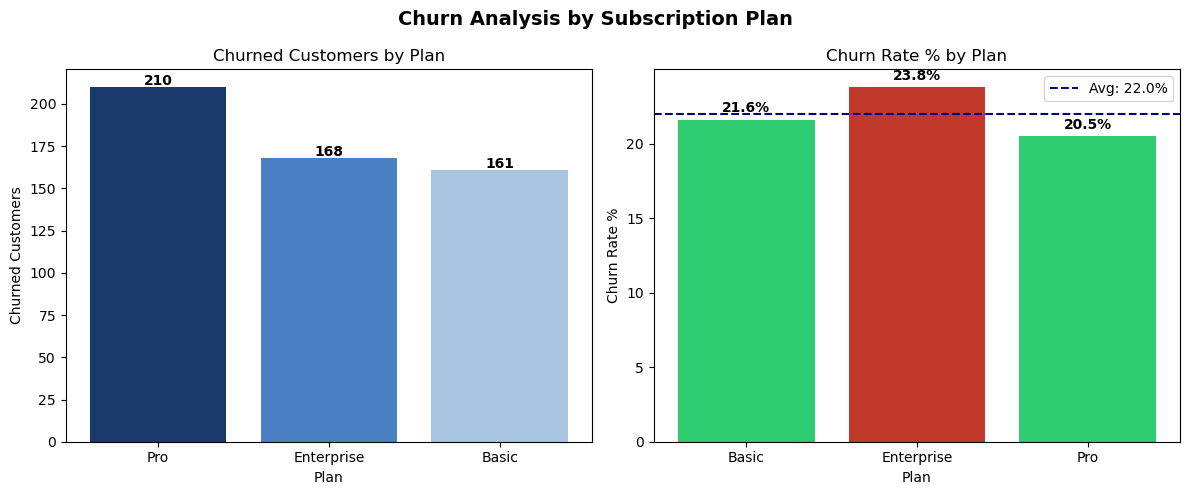


📌 Insight: Which plan has the highest churn rate?
   Highest: Enterprise at 23.8%
   Lowest:  Pro at 20.5%


In [ ]:
#EDA: Churn by Plan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Analysis by Subscription Plan', fontsize=14, fontweight='bold')

# Merge churn events with subscriptions to get plan at churn
churn_with_plan = net_churn.merge(
    subscriptions[['account_id', 'plan_tier', 'mrr_amount']]
    .drop_duplicates('account_id'),
    on='account_id', how='left'
)

# Chart 1: Churn count by plan
churn_by_plan = churn_with_plan['plan_tier'].value_counts()
axes[0].bar(churn_by_plan.index, churn_by_plan.values,
            color=['#1B3A6B', '#4A7FC1', '#A8C4E0'])
axes[0].set_title('Churned Customers by Plan')
axes[0].set_xlabel('Plan')
axes[0].set_ylabel('Churned Customers')
for i, v in enumerate(churn_by_plan.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Chart 2: Churn rate by plan
# FIX: accounts already has plan_tier column — rename subscription's
# plan_tier to sub_plan_tier to avoid column conflict on merge
plan_totals = accounts.merge(
    subscriptions[['account_id', 'plan_tier']]
    .drop_duplicates('account_id')
    .rename(columns={'plan_tier': 'sub_plan_tier'}),
    on='account_id', how='left'
)

# Use sub_plan_tier (from subscriptions) — source of truth for plan
churn_rate_by_plan = (
    plan_totals.groupby('sub_plan_tier')['churn_flag'].mean() * 100
).round(1)

colors = ['#C0392B' if v > churn_rate_by_plan.mean() else '#2ECC71'
          for v in churn_rate_by_plan.values]
axes[1].bar(churn_rate_by_plan.index, churn_rate_by_plan.values, color=colors)
axes[1].set_title('Churn Rate % by Plan')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Churn Rate %')
axes[1].axhline(y=churn_rate_by_plan.mean(), color='navy',
                linestyle='--', label=f'Avg: {churn_rate_by_plan.mean():.1f}%')
axes[1].legend()
for i, v in enumerate(churn_rate_by_plan.values):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/eda_churn_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Which plan has the highest churn rate?")
print(f"   Highest: {churn_rate_by_plan.idxmax()} at {churn_rate_by_plan.max()}%")
print(f"   Lowest:  {churn_rate_by_plan.idxmin()} at {churn_rate_by_plan.min()}%")

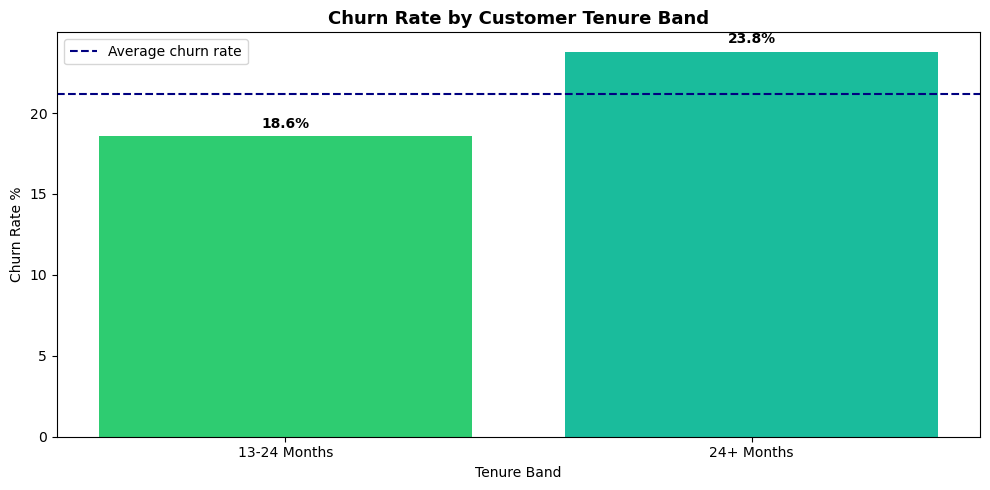


📌 Tenure insight:
              churned  total  churn_rate
tenure_band                             
0-3 Months        NaN    NaN         NaN
4-6 Months        NaN    NaN         NaN
7-12 Months       NaN    NaN         NaN
13-24 Months    33.00 177.00       18.60
24+ Months      77.00 323.00       23.80


In [ ]:
#EDA: Churn by Tenure Band
# Tenure months from signup_date to today
# Fix: use days / 30.44 instead of np.timedelta64(1, 'M')
today = pd.Timestamp.today()

accounts['tenure_months'] = (
    (today - accounts['signup_date']).dt.days / 30.44
).astype(int)

# Tenure band
def tenure_band(m):
    if m <= 3:    return '0-3 Months'
    elif m <= 6:  return '4-6 Months'
    elif m <= 12: return '7-12 Months'
    elif m <= 24: return '13-24 Months'
    else:         return '24+ Months'

accounts['tenure_band'] = accounts['tenure_months'].apply(tenure_band)

band_order = ['0-3 Months', '4-6 Months', '7-12 Months', '13-24 Months', '24+ Months']
churn_by_tenure = (
    accounts.groupby('tenure_band')['churn_flag']
    .agg(['sum', 'count'])
    .reindex(band_order)
)
churn_by_tenure['churn_rate'] = (
    churn_by_tenure['sum'] / churn_by_tenure['count'] * 100
).round(1)
churn_by_tenure.columns = ['churned', 'total', 'churn_rate']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    churn_by_tenure.index,
    churn_by_tenure['churn_rate'],
    color=['#C0392B', '#E67E22', '#F1C40F', '#2ECC71', '#1ABC9C']
)
ax.set_title('Churn Rate by Customer Tenure Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Band')
ax.set_ylabel('Churn Rate %')
ax.axhline(y=churn_by_tenure['churn_rate'].mean(), color='navy',
           linestyle='--', label='Average churn rate')
ax.legend()
for bar, val in zip(bars, churn_by_tenure['churn_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/eda_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Tenure insight:")
print(churn_by_tenure[['churned', 'total', 'churn_rate']])

In [ ]:
#Build Usage Groups & Risk Segments
# Monthly usage per account
usage_monthly = (
    usage.merge(
        subscriptions[['subscription_id', 'account_id']],
        on='subscription_id'
    )
    .groupby('account_id')['usage_count']
    .sum()
    .reset_index()
    .rename(columns={'usage_count': 'total_usage_count'})
)

# Usage thresholds: 33rd and 66th percentile
p33 = usage_monthly['total_usage_count'].quantile(0.33)
p66 = usage_monthly['total_usage_count'].quantile(0.66)

def get_usage_group(val):
    if val <= p33:   return 'Low'
    elif val <= p66: return 'Medium'
    else:            return 'High'

usage_monthly['usage_group'] = usage_monthly['total_usage_count'].apply(get_usage_group)

print(f"Usage thresholds:")
print(f"  Low    : ≤ {p33:.0f} total usage")
print(f"  Medium : {p33:.0f} – {p66:.0f}")
print(f"  High   : > {p66:.0f}")
print(f"\nUsage group distribution:")
print(usage_monthly['usage_group'].value_counts())

# Support ticket count per account
ticket_counts = (
    tickets.groupby('account_id')['ticket_id']
    .count()
    .reset_index()
    .rename(columns={'ticket_id': 'ticket_count'})
)

# Build master customer table
master = (
    accounts
    .merge(
        active_subs[['account_id', 'plan_tier', 'mrr_amount', 'auto_renew_flag']]
        .drop_duplicates('account_id'),
        on='account_id', how='left'
    )
    .merge(usage_monthly[['account_id', 'total_usage_count', 'usage_group']],
           on='account_id', how='left')
    .merge(ticket_counts, on='account_id', how='left')
)

master['total_usage_count'] = master['total_usage_count'].fillna(0)
master['ticket_count']      = master['ticket_count'].fillna(0)
master['usage_group']       = master['usage_group'].fillna('Low')

# Risk Segment Logic
mrr_median = master['mrr_amount'].median()
print(f"\nMRR median (High Value threshold): ${mrr_median:,.2f}")

def risk_segment(row):
    high_value   = row['mrr_amount'] > mrr_median if pd.notna(row['mrr_amount']) else False
    low_usage    = row['usage_group'] == 'Low'
    high_tickets = row['ticket_count'] >= 3
    med_tickets  = row['ticket_count'] >= 2

    if high_value and (low_usage or high_tickets):
        return 'High Value At Risk'
    elif low_usage and med_tickets:
        return 'At Risk'
    elif low_usage or med_tickets:
        return 'Watchlist'
    else:
        return 'Healthy'

master['risk_segment'] = master.apply(risk_segment, axis=1)

print("\nRisk Segment Distribution:")
print(master['risk_segment'].value_counts())

Usage thresholds:
  Low    : ≤ 419 total usage
  Medium : 419 – 578
  High   : > 578

Usage group distribution:
usage_group
High      170
Medium    165
Low       165
Name: count, dtype: int64

MRR median (High Value threshold): $1,323.00

Risk Segment Distribution:
risk_segment
High Value At Risk    213
Watchlist             186
At Risk                78
Healthy                23
Name: count, dtype: int64


In [ ]:
#Revenue at Risk
rev_at_risk   = master[
    master['risk_segment'].isin(['At Risk', 'High Value At Risk'])
]['mrr_amount'].sum()

total_mrr_py  = master['mrr_amount'].sum()

print(f"{'Revenue at Risk':<25}: ${rev_at_risk:>12,.2f}")
print(f"{'Total MRR':<25}: ${total_mrr_py:>12,.2f}")
print(f"{'% of MRR at Risk':<25}: {rev_at_risk / total_mrr_py * 100:.1f}%")

# MRR breakdown by risk segment
risk_mrr = (
    master.groupby('risk_segment')['mrr_amount']
    .agg(customers='count', total_mrr='sum')
    .sort_values('total_mrr', ascending=False)
)
risk_mrr['mrr_pct'] = (risk_mrr['total_mrr'] / total_mrr_py * 100).round(1)
risk_mrr['total_mrr'] = risk_mrr['total_mrr'].apply(lambda x: f'${x:,.2f}')

print("\nMRR by Risk Segment:")
print(risk_mrr)

# Churn rate by usage group
churn_by_usage = (
    master.groupby('usage_group')['churn_flag']
    .agg(['sum', 'count'])
)
churn_by_usage['churn_rate'] = (
    churn_by_usage['sum'] / churn_by_usage['count'] * 100
).round(1)
churn_by_usage.columns = ['churned', 'total', 'churn_rate_%']

print("\n📌 Churn Rate by Usage Group:")
print(churn_by_usage)
print("\n📌 Insight: Do low-usage customers churn more? ☝️ Check the table above.")

Revenue at Risk          : $1,031,883.00
Total MRR                : $1,337,420.00
% of MRR at Risk         : 77.2%

MRR by Risk Segment:
                    customers    total_mrr  mrr_pct
risk_segment                                       
High Value At Risk        213  $983,890.00    73.60
Watchlist                 186  $246,755.00    18.50
Healthy                    23   $58,782.00     4.40
At Risk                    78   $47,993.00     3.60

📌 Churn Rate by Usage Group:
             churned  total  churn_rate_%
usage_group                              
High              41    170         24.10
Low               31    165         18.80
Medium            38    165         23.00

📌 Insight: Do low-usage customers churn more? ☝️ Check the table above.


In [ ]:
#Export Processed Data for Power BI
import os
os.makedirs('../data/processed', exist_ok=True)

# 1. Master customer table with risk segments
master.to_csv('../data/processed/master_customers.csv', index=False)

# 2. Monthly churn trend
churn_trend = (
    net_churn
    .groupby(net_churn['churn_date'].dt.to_period('M'))
    .agg(churned_customers=('account_id', 'nunique'))
    .reset_index()
)
churn_trend['churn_date'] = churn_trend['churn_date'].astype(str)
churn_trend.to_csv('../data/processed/monthly_churn_trend.csv', index=False)

# 3. Churn by reason
churn_by_reason = (
    net_churn['reason_code']
    .value_counts()
    .reset_index()
)
churn_by_reason.columns = ['reason_code', 'churn_count']
churn_by_reason.to_csv('../data/processed/churn_by_reason.csv', index=False)

# 4. MRR by risk segment (for Power BI revenue risk page)
risk_export = (
    master.groupby('risk_segment')
    .agg(
        customers=('account_id', 'count'),
        total_mrr=('mrr_amount', 'sum')
    )
    .reset_index()
)
risk_export.to_csv('../data/processed/mrr_by_risk_segment.csv', index=False)

print("Processed files saved ✅")
print(os.listdir('../data/processed/'))

Processed files saved ✅
['churn_by_reason.csv', 'master_customers.csv', 'monthly_churn_trend.csv', 'mrr_by_risk_segment.csv']


In [ ]:
# EDA Summary
print("=" * 55)
print("  EDA SUMMARY — KEY FINDINGS FOR DASHBOARD DESIGN")
print("=" * 55)
print(f"1. Overall churn rate         : {accounts['churn_flag'].mean()*100:.1f}%")
print(f"2. Highest churn plan         : {churn_rate_by_plan.idxmax()} "
      f"({churn_rate_by_plan.max():.1f}%)")
print(f"3. Lowest churn plan          : {churn_rate_by_plan.idxmin()} "
      f"({churn_rate_by_plan.min():.1f}%)")
print(f"4. Revenue at risk            : ${rev_at_risk:,.2f} "
      f"({rev_at_risk/total_mrr_py*100:.1f}% of MRR)")
print(f"5. High Value At Risk count   : "
      f"{(master['risk_segment']=='High Value At Risk').sum()} customers")
print(f"6. At Risk count              : "
      f"{(master['risk_segment']=='At Risk').sum()} customers")
print(f"7. Low usage customers        : "
      f"{(master['usage_group']=='Low').sum()}")
print(f"8. Avg tickets (churned)      : "
      f"{master[master['churn_flag']==1]['ticket_count'].mean():.1f}")
print(f"9. Avg tickets (active)       : "
      f"{master[master['churn_flag']==0]['ticket_count'].mean():.1f}")
print(f"10. Satisfaction score NULLs  : "
      f"{tickets['satisfaction_score'].isnull().sum()} "
      f"({tickets['satisfaction_score'].isnull().mean()*100:.1f}%)")
print(f"11. Open support tickets      : "
      f"{tickets['closed_at'].isnull().sum()}")
print(f"12. Feedback text NULLs       : "
      f"{churn['feedback_text'].isnull().sum()} "
      f"({churn['feedback_text'].isnull().mean()*100:.1f}%)")
print("=" * 55)

  EDA SUMMARY — KEY FINDINGS FOR DASHBOARD DESIGN
1. Overall churn rate         : 22.0%
2. Highest churn plan         : Enterprise (23.8%)
3. Lowest churn plan          : Pro (20.5%)
4. Revenue at risk            : $1,031,883.00 (77.2% of MRR)
5. High Value At Risk count   : 213 customers
6. At Risk count              : 78 customers
7. Low usage customers        : 165
8. Avg tickets (churned)      : 3.9
9. Avg tickets (active)       : 4.0
10. Satisfaction score NULLs  : 825 (41.2%)
11. Open support tickets      : 0
12. Feedback text NULLs       : 148 (24.7%)
